In [ ]:
import sys
import os
import h5py
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src import io, vis, timesync
import xarray as xr


In [ ]:
raw_path = '/home/ptarabishi/projects/maui_codebook/data/raw/TSeries_20251217-101'
processed_path = '/home/ptarabishi/projects/maui_codebook/data/processed/TSeries_20251217-101/'
cluster_labels, signal = io.load_clusters(processed_path)
# scope_timestamps = timesync.extract_scope_timestamps(raw_path)
scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)
# cluster_labels=np.array(cluster_labels)
# print(cluster_labels.shape)
# cluster_labels = np.reshape(cluster_labels, [brain_dim[2], brain_dim[0], brain_dim[1]])
# print(cluster_labels.shape)

: 

In [ ]:
with h5py.File(f'{processed_path}scope_timestamps.h5', 'w') as hf:
    hf.create_dataset('my_data', data=scope_timestamps)

In [ ]:
def convert_frametimestamps_to_datetime(timestamps_dataframe):
    # this selects the first slice fo teh volume to use as our timestamp
    t0 = np.datetime64('2025-01-01T00:00:00')
    volume_deltas = np.round(timestamps_dataframe[::31]).astype('<m8[ms]')
    dt_timestamps = t0 + volume_deltas
    return dt_timestamps

timestamps = convert_frametimestamps_to_datetime(scope_timestamps)
print(timestamps)

NameError: name 'scope_timestamps' is not defined

In [ ]:
# transform signal to xarray
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': timestamps.squeeze()}
)

0 [5, 100]
1 [10, 15]


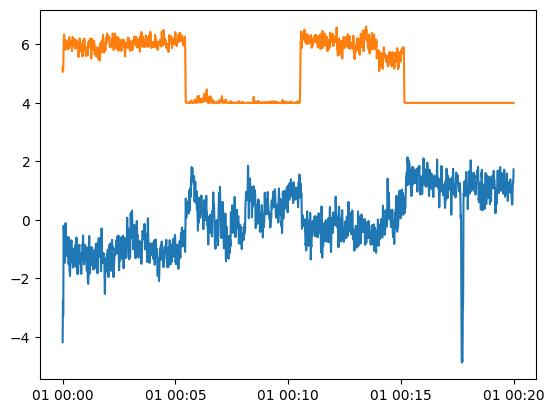

In [ ]:
rois = [[5,100],[10,15]]
# print(rois[0][1])
yshift=5
for index, roi in enumerate(rois):
    print(index, roi)
    to_plot = signal_xr.isel(zposs=roi[0], roi=roi[1])
    plt.plot(signal_xr.coords['time'], to_plot+(yshift*index))

In [ ]:
vis.plot_zscored_activity(rois, signal_xr)
vis.plot_spatial_location(rois, cluster_labels,brain_dimensions=brain_dim)

NameError: name 'rois' is not defined